# Towards biologically plausible phosphene simulation for the differentiable optimization of visual thalamic prostheses

This notebook demonstrates `dynaphos_lgn`: a phosphene simulator whose electrodes sit in the **lateral geniculate nucleus** rather than in cortex, with phosphene positions, sizes and orientations read from a reconstructed macaque LGN atlas (Erwin et al., 1999) instead of chosen by hand.

Three things follow from that:

- **Phosphene locations are not a free input.** An electrode sits in a voxel of the atlas, and that voxel's recorded eccentricity and inclination become the phosphene's position - so the simulator is always built from tissue, and the phosphene map comes back out rather than going in. `dynaphos_lgn.build.build_simulator` is the single entry point that wires atlas -> Jacobian -> magnification -> electrodes -> simulator.
- **Phosphenes are ellipses.** The recruitment radius in millimetres of tissue is stretched by the two principal magnifications of the atlas's local Jacobian, so a phosphene's elongation and orientation are read off the anatomy at that electrode.
- **One nucleus covers one hemifield.** Each LGN represents only the contralateral visual field. The bilateral counterpart of this notebook, `demo_simulator_lgn_bilateral.ipynb`, covers both.

Once built, the simulator is called with a stimulation vector, returns an image, and behaves like any other differentiable Dynaphos simulator: `reset()` between trials, `get_state()` for internals, gradients flow through the whole thing.

> **Provenance.** Almost nothing about LGN stimulation has been measured. The current-spread constant is transplanted from macaque V1, the temporal dynamics and rheobase from human V1, and the koniocellular receptive fields from owl monkey. `dynaphos_lgn/README.md` lists the known gaps; the config comments say where each number came from. Treat the pictures below as a working model, not as measurements.

## 0. Imports

##### Import statements

In [1]:
import sys
sys.path.append('./..')
import logging

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

from dynaphos import utils
from dynaphos.utils import Map, get_data_kwargs, to_numpy
from dynaphos.image_processing import canny_processor, sobel_processor

from dynaphos_lgn.build import build_simulator
from dynaphos_lgn.lgn_utils import get_electrode_layout
from dynaphos_lgn.params import require
from dynaphos_lgn.simulator import LGNPhospheneSimulator as PhospheneSimulator

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

ATLAS_DIR = '../data/Erwin_Atlas'

##### Some plotting functions

In [2]:
def plot_fov(params, ax):
    """Plot a polar grid and visualize the field of view of simulation."""
    fov = params['run']['view_angle']
    org = params['run']['origin']

    # Plot the simulation FOV (square)
    x1, x2 = org[0]-fov//2, org[0] + fov//2
    y1, y2 = org[1]-fov//2, org[1] + fov//2
    ax.plot([x1,x1,x2,x2,x1], [y1,y2,y2,y1,y1], color='k')

    # Plot the radial lines
    for angle in np.linspace(-np.pi,np.pi,9) :
        r = []
        phi = []
        for radius in np.linspace(0,60,1000):
            r.append(radius)
            phi.append(angle)

        visual_field = Map(r = np.array(r), phi = np.array(phi))
        ax.plot(*visual_field.cartesian, 'k:',linewidth=.5)


    # Plot the concentric grid lines
    for radius in np.linspace(1,60,8):
        r = []
        phi = []
        for angle in np.linspace(-np.pi,np.pi,100):
            r.append(radius)
            phi.append(angle)

        visual_field = Map(r = np.array(r), phi = np.array(phi))
        ax.plot(*visual_field.cartesian, 'k:',linewidth=.5)

    ax.spines[['left', 'bottom']].set_position('center')
    ax.spines[['right', 'top']].set_visible(False)

    # LGN electrodes are kept inside the 16 deg FOV, so zoom in on
    # it instead of autoscaling to the full 60 deg grid -- otherwise
    # every phosphene lands in a few pixels.
    #ax.set(xticks=[-60,-30, 0,30,60], yticks=[-60,-30, 0,30,60])
    ticks = [-fov, -fov//2, 0, fov//2, fov]
    ax.set(xticks=ticks, yticks=ticks)
    ax.set_xlim(-1.1*fov, 1.1*fov)
    ax.set_ylim(-1.1*fov, 1.1*fov)
    ax.set_aspect('equal')


def atlas_geometry(params):
    """Voxel size and Horsley-Clarke origin, straight from the config."""
    origin = require(params, 'atlas.horsley_clarke_origin_mm')
    return (require(params, 'atlas.voxel_size_mm'),
            np.array([origin['ml'], origin['dv'], origin['ap']]))


def index_to_horsley_clarke(params, voxel_indices):
    """(n, 3) atlas indices -> (n, 3) Horsley-Clarke coordinates in mm."""
    voxel_size, origin = atlas_geometry(params)
    return np.asarray(voxel_indices) * voxel_size + origin


def plot_lgn_section(params, atlas, ax, ap_mm, field='layer'):
    """Plot one coronal section through the LGN atlas: the sheet the
    electrodes sit in. `field='layer'` shows the six laminae from
    LAYERS.DAT, `field='eccentricity'` the retinotopy from ECC.DAT.
    Returns the artist, so a colorbar can be attached.
    """
    voxel_size, origin = atlas_geometry(params)
    k = int(round((ap_mm - origin[2]) / voxel_size))
    n_ml, n_dv, _ = atlas.atlas_shape
    # Rows are ML, columns are DV, so the section is drawn in the plane
    # the laminae curve in.
    extent = [origin[1], origin[1] + n_dv * voxel_size,
              origin[0], origin[0] + n_ml * voxel_size]

    valid = atlas.valid[:, :, k]
    if field == 'layer':
        image = np.where(valid, atlas.layer[:, :, k], np.nan)
        artist = ax.imshow(image, origin='lower', extent=extent,
                           cmap='tab10', vmin=0.5, vmax=10.5,
                           interpolation='nearest')
    elif field == 'eccentricity':
        image = np.where(valid, atlas.eccentricity_deg[:, :, k], np.nan)
        artist = ax.imshow(image, origin='lower', extent=extent,
                           cmap='viridis', interpolation='nearest')
    else:
        raise ValueError(f"Unknown field {field!r}.")

    ax.set_aspect('equal')
    ax.set(xlabel='dorsal-ventral (mm)', ylabel='medial-lateral (mm)')
    # Crop to the tissue rather than the (mostly empty) grid.
    rows, cols = np.nonzero(valid)
    if len(rows):
        pad = 10 * voxel_size
        ax.set_xlim(origin[1] + cols.min() * voxel_size - pad,
                    origin[1] + cols.max() * voxel_size + pad)
        ax.set_ylim(origin[0] + rows.min() * voxel_size - pad,
                    origin[0] + rows.max() * voxel_size + pad)
    return artist

## 1. Basic usage

#### Initialization
The simulator is initialized from a configuration file (`params_lgn.yaml`) and the atlas - not from a map of phosphene coordinates: those are read out of the atlas at whichever voxels the electrodes occupy. `build_simulator` does the whole chain in one call and hands back every intermediate object, so nothing has to be rebuilt to inspect it.

In [3]:
# Load the simulator configuration file (and adjust to preferences).
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds

# The shipped config places electrodes out to 20 deg eccentricity, which
# is well outside the rendered 16 deg field of view. Keep them inside it
# so the figures show every phosphene. (The simulator warns when they do
# not.)
params['electrodes']['max_eccentricity_deg'] = 6.0

In [4]:
# Get electrode locations (and with them, the phosphene coordinates).
n_phosphenes = 100
params['electrodes']['n_electrodes'] = n_phosphenes

## By default the electrodes are spread evenly in the visual field by
## farthest-point sampling over atlas voxels. To place them
## yourself, pass voxel_indices= or visual_field_targets= instead; both
## are shown in section 2.

In [5]:
# Initialize simulator
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)

atlas = parts['atlas']
n_phosphenes = simulator.num_phosphenes
phosphene_coords = simulator.array.visual_field

print(simulator.describe())

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


LGNElectrodeArray: 100 electrodes
  nucleus           : left LGN -> right hemifield
  eccentricity      : 0.20 - 6.00 deg
  I_max             : 100.0 uA
  spread radius     : 385 um nominal, 584 um gathered
  candidates        : 6667 per electrode (stride 2, each standing for 8 voxels)
  scatter points    : 512
  render mode       : 90 ellipse, 10 scatter
Electrode confidence flags (100 electrodes):
     4 / 100  central-1 deg, isotropic by construction
    10 / 100  Jacobian unreliable beyond its fit neighbourhood
   100 / 100  footprint touches placeholder/sentinel voxels
    31 / 100  footprint spans both magno and parvo tissue
     0 / 100  sized by scalar magnification (forced circular)


#### Simulation
Each frame, the simulator is called with a vector of per-electrode stimulation amplitudes. It keeps a stimulation history across calls, and `reset()` clears it.

In [6]:
# Stimulation amplitude
amplitude = 100.e-6 # Ampere (default 100uA)

# Stimulation vector
stim = amplitude * torch.ones(n_phosphenes) # (All electrodes are activated)

# Reset and call the simulator
simulator.reset()
phosphenes = simulator(stim)

#### Visualization
The output of the simulator is an image (as torch tensor) that represents the visual experience of the implant user.

Text(0.5, 1.0, 'Simulated phosphenes')

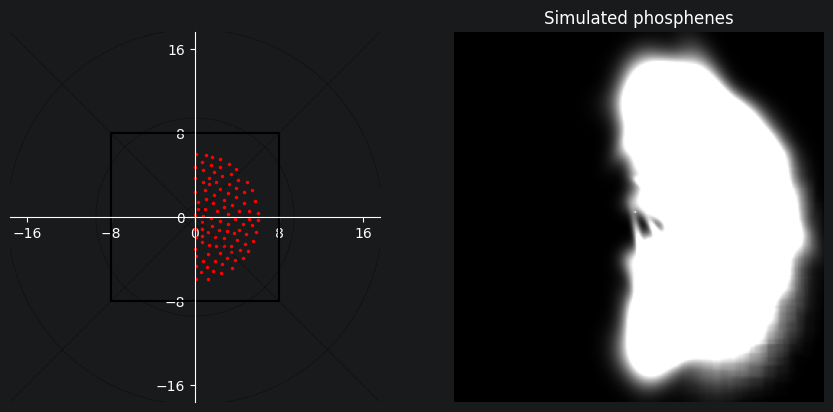

In [7]:
# Visualize
fig, axs = plt.subplots(1,2, figsize=(10.5,5))

# Plot the phosphene locations in the visual field
axs[0].plot(*phosphene_coords.cartesian, 'r.', markersize=3)
plot_fov(params, axs[0])

# Plot the simulated phosphene image
axs[1].imshow(phosphenes, cmap='gray', origin='lower') # (origin is lower left)
axs[1].axis('off')
axs[1].set_title('Simulated phosphenes')

**Only the right half of the field is covered.** One LGN represents the contralateral hemifield. The ipsilateral-hemifield voxels in `INCL.DAT` carry only a coarse ±135° placeholder - Erwin et al. had 17 ipsilateral recording sites, too few to resolve - and `atlas.exclude_ipsi_flat_inclination` drops them by default. Simulating a full field means simulating two implants and summing them (see the bilateral notebook).

**The phosphenes merge into one mass.** At 100 µA a phosphene here has σ ≈ 0.8°, while 100 electrodes inside the 6° window sit roughly 0.75° apart, so neighbours overlap almost completely. Phosphene size is the *least* certain quantity in this model: the excitability constant K = 675 µA/mm² is transplanted from macaque V1 and unvalidated for LGN, and the resulting sizes run 4–6× larger than the Vurro et al. (2014) cross-reference (see the README's known gaps). So read the usable electrode count as a property of the current parameters, not as a claim about the LGN.

#### A closer look: phosphene shape
Dropping to 25 electrodes separates them, and shows that a phosphene here is an **ellipse**, not a disc: the recruitment sigma in millimetres of tissue is stretched by the *two* principal magnifications of the atlas's local Jacobian, so its elongation and orientation are read off the tissue.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Phosphene sigma at 100 uA over 25 electrodes:
  major axis : 0.79 deg (median)
  minor axis : 0.47 deg (median)
  elongation : 1.73x (median)


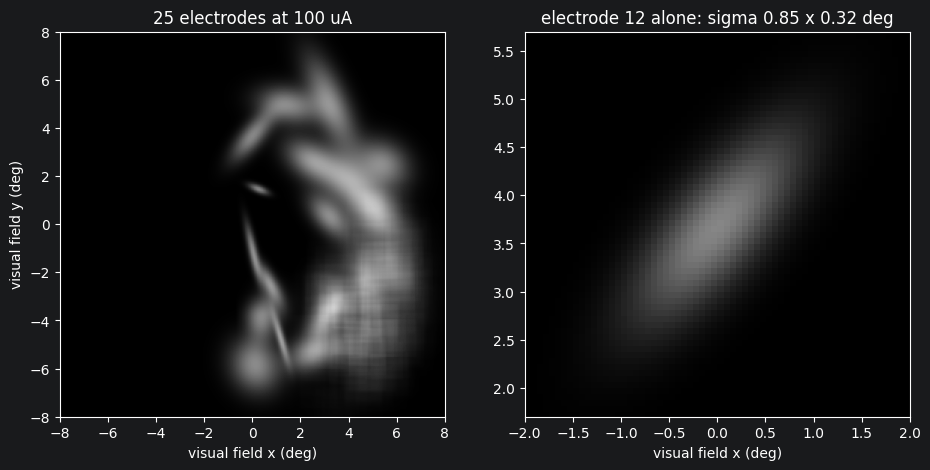

In [8]:
# Same config, fewer electrodes
params_small = utils.load_params('../config/params_lgn.yaml')
params_small['electrodes']['max_eccentricity_deg'] = 6.0
params_small['electrodes']['n_electrodes'] = 25
simulator_small, _ = build_simulator(params_small, atlas_dir=ATLAS_DIR)

simulator_small.reset()
phosphenes_small = simulator_small(
    100.e-6 * torch.ones(simulator_small.num_phosphenes))

half = params_small['run']['view_angle'] / 2
extent = [-half, half, -half, half]

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(phosphenes_small, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
axs[0].set(xlabel='visual field x (deg)', ylabel='visual field y (deg)',
           title='25 electrodes at 100 uA')

# Zoom on a single, isolated electrode, so one phosphene is unobstructed
xy = simulator_small.array.vf_xy
distance = np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=-1)
np.fill_diagonal(distance, np.inf)
isolated = int(distance.min(axis=1).argmax())
cx, cy = xy[isolated]

one_electrode = torch.zeros(simulator_small.num_phosphenes)
one_electrode[isolated] = 100.e-6
simulator_small.reset()
single = simulator_small(one_electrode)

major, minor = simulator_small.array.phosphene_sigma_deg(100.)
axs[1].imshow(single, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
axs[1].set_xlim(cx - 2, cx + 2)
axs[1].set_ylim(cy - 2, cy + 2)
axs[1].set(xlabel='visual field x (deg)',
           title=f'electrode {isolated} alone: sigma '
                 f'{major[isolated]:.2f} x {minor[isolated]:.2f} deg')

print(f'Phosphene sigma at 100 uA over {simulator_small.num_phosphenes} '
      f'electrodes:')
print(f'  major axis : {np.nanmedian(major):.2f} deg (median)')
print(f'  minor axis : {np.nanmedian(minor):.2f} deg (median)')
print(f'  elongation : {np.nanmedian(major / minor):.2f}x (median)')

#### An optional model: `AnisotropicGradientMagnification`

The `jacobian` model above (the default) looks up each electrode's magnification from the per-voxel Jacobian atlas -- a ~100 MB array fit once and cached to `JACOBIAN.npz`, but still held and indexed at build time for every array. `AnisotropicGradientMagnification` bins that same per-voxel field, once, into a small 2-D `(eccentricity, inclination)` lookup table, so nothing at build time touches the full-resolution Jacobian -- only a few thousand table cells. It is the anisotropic counterpart of the `atlas_gradient` model (which already does this but discards the ellipse and returns a circle); this one keeps major, minor *and* orientation.

Select it with `params['magnification']['model'] = 'anisotropic_gradient'`; nothing else about the simulator changes -- same call interface, same ellipse rendering, same confidence flags. The table's bin widths, minimum voxels per bin and outlier gate live under `magnification.anisotropic_gradient` in the config; the defaults are chosen to isolate (not blur) a real ~5-10 deg discontinuity in the atlas's retinotopy around inclination -15 deg.

The cell below rebuilds the same 25-electrode demo with both models and compares per-electrode phosphene sigma. Build time in this cell is not a fair comparison of the two models: loading the atlas and `JACOBIAN.npz` from disk dominates both calls, since `build_simulator` reloads them from scratch every time regardless of which magnification model is selected. The table's actual saving is elsewhere -- once the atlas and Jacobian are loaded, an `AnisotropicGradientMagnification` table is small enough to keep around (or serialise) on its own, without holding the full per-voxel Jacobian in memory for repeated electrode-array rebuilds within a session.

The `scalar_magnification` flag count printed below is the check that `magnification.model` actually took effect: `build_simulator` still loads the full Jacobian atlas either way (the table itself is built from it), but `build_electrode_array` now only hands the raw per-voxel Jacobian to an electrode array when `magnification.model` is `'jacobian'` -- for any other choice, sizing goes through the chosen model exclusively, which is why every electrode below is flagged `scalar_magnification` under `anisotropic_gradient` and none are under `jacobian`. The two sigma columns therefore differ slightly: `anisotropic_gradient` reads off a coarse (E, I) table instead of each electrode's own voxel.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


anisotropic_gradient table: (46, 90) (eccentricity x inclination) bins, 82% reliable

model                    build (s)   sigma major (deg)   sigma minor (deg)    scalar_magnification
jacobian                     10.99               0.794               0.470                    0/25
anisotropic_gradient         11.05               0.786               0.472                   25/25


[Text(0.5, 0, 'visual field x (deg)'),
 Text(0, 0.5, 'visual field y (deg)'),
 Text(0.5, 1.0, "25 electrodes, 'anisotropic_gradient' model")]

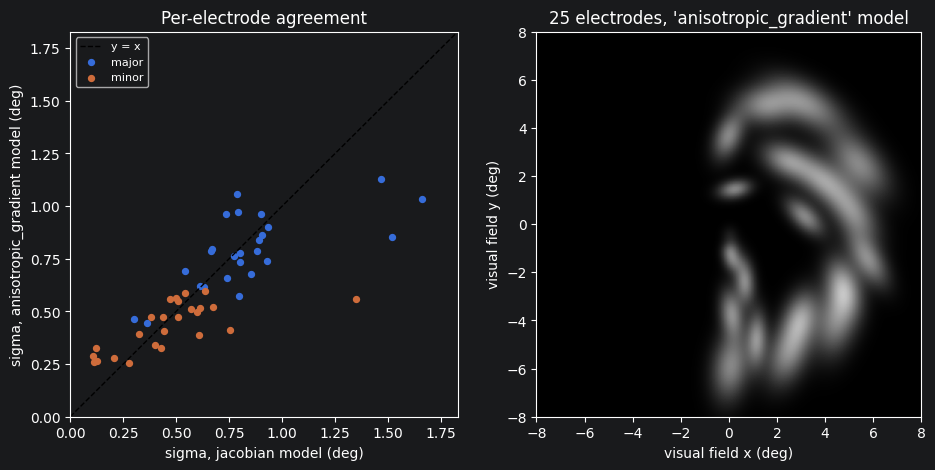

In [9]:
import time

def build_with_model(model_name, n_electrodes=25):
    p = utils.load_params('../config/params_lgn.yaml')
    p['electrodes']['max_eccentricity_deg'] = 6.0
    p['electrodes']['n_electrodes'] = n_electrodes
    p['magnification']['model'] = model_name  # 'jacobian' (default),
                                               # 'atlas_gradient',
                                               # 'anisotropic_gradient' or
                                               # 'malpeli_density'
    t0 = time.time()
    sim, parts = build_simulator(p, atlas_dir=ATLAS_DIR)
    elapsed = time.time() - t0
    major, minor = sim.array.phosphene_sigma_deg(100.)
    return dict(simulator=sim, parts=parts, elapsed=elapsed,
                major=major, minor=minor)

jacobian = build_with_model('jacobian')
anisotropic = build_with_model('anisotropic_gradient')

table = anisotropic['parts']['magnification']
print(f"anisotropic_gradient table: {table.major_grid.shape} "
      f"(eccentricity x inclination) bins, "
      f"{table.reliable_grid.mean() * 100:.0f}% reliable\n")

print(f"{'model':<22}{'build (s)':>12}{'sigma major (deg)':>20}"
      f"{'sigma minor (deg)':>20}{'scalar_magnification':>24}")
for name, result in [('jacobian', jacobian),
                      ('anisotropic_gradient', anisotropic)]:
    array = result['simulator'].array
    n_scalar = int(array.flags.scalar_magnification.sum())
    print(f"{name:<22}{result['elapsed']:>12.2f}"
          f"{np.nanmedian(result['major']):>20.3f}"
          f"{np.nanmedian(result['minor']):>20.3f}"
          f"{n_scalar:>21d}/{array.n_electrodes}")

# Per-electrode agreement: same seed -> same voxel_indices for both
# builds, so sigma[i] refers to the same electrode in both arrays.
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
lim = [0, float(np.nanmax([jacobian['major'], anisotropic['major']])) * 1.1]
axs[0].plot(lim, lim, 'k--', linewidth=1, label='y = x')
axs[0].scatter(jacobian['major'], anisotropic['major'], label='major', s=18)
axs[0].scatter(jacobian['minor'], anisotropic['minor'], label='minor', s=18)
axs[0].set(xlabel='sigma, jacobian model (deg)',
           ylabel='sigma, anisotropic_gradient model (deg)',
           title='Per-electrode agreement', xlim=lim, ylim=lim)
axs[0].legend(fontsize=8)

# The same 25-electrode phosphene image, rendered from the table model.
sim_a = anisotropic['simulator']
sim_a.reset()
phosphenes_a = sim_a(100.e-6 * torch.ones(sim_a.num_phosphenes))
axs[1].imshow(phosphenes_a, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
axs[1].set(xlabel='visual field x (deg)', ylabel='visual field y (deg)',
           title="25 electrodes, 'anisotropic_gradient' model")

#### Isotropic reference: the original Malpeli density magnification

`MalpeliDensityMagnification` does not touch the fitted Jacobian atlas at all. It starts from Malpeli, Lee & Baker (1996)'s closed-form parvocellular cell-density equation (Eq. 1, `magnification.malpeli.parvo` in the config) and converts cells/deg^2 into a tissue magnification via a volumetric cell density (taken from the atlas's own `CELLS.DAT` through `from_atlas`) and an assumed projection-column thickness. The thickness is not fixed by the formula, so the model reports an interval rather than a point estimate, and it is isotropic by construction -- `major_deg_per_mm == minor_deg_per_mm` everywhere, with no orientation to report.

Both routes ultimately trace back to the same 415 recording sites (the Erwin atlas reconstruction itself started from Malpeli's data), so agreement between them is not an independent cross-check -- see the module docstring in `magnification.py`. What the comparison below actually shows is whether `anisotropic_gradient`'s areal-equivalent scale sits in the same ballpark as the closed-form density route (a check on magnitude), and how much of the measured anisotropy an isotropic model necessarily discards (a check on shape). Per the class docstring: treat Malpeli as the magnitude estimate and the Jacobian-derived route as the shape estimate, not as two independent measurements of the same thing.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


model                    sigma major (deg)   sigma minor (deg)
anisotropic_gradient                 0.786               0.472
malpeli_density                      0.793               0.793


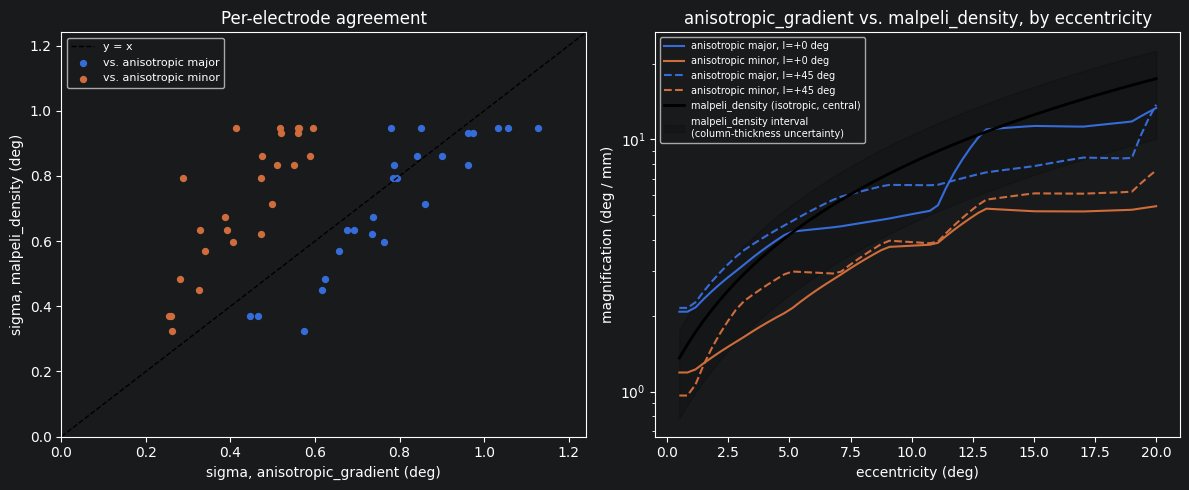

In [10]:
from dynaphos_lgn.magnification import MalpeliDensityMagnification

# Build the same 25-electrode array with the isotropic, Malpeli-density
# model, and compare it against the anisotropic_gradient model above.
malpeli = build_with_model('malpeli_density')

print(f"{'model':<22}{'sigma major (deg)':>20}{'sigma minor (deg)':>20}")
for name, result in [('anisotropic_gradient', anisotropic),
                      ('malpeli_density', malpeli)]:
    print(f"{name:<22}{np.nanmedian(result['major']):>20.3f}"
          f"{np.nanmedian(result['minor']):>20.3f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Left: per-electrode agreement. malpeli_density is isotropic, so its
# single value is plotted against both of anisotropic_gradient's axes.
lim = [0, float(np.nanmax([anisotropic['major'], malpeli['major']])) * 1.1]
axs[0].plot(lim, lim, 'k--', linewidth=1, label='y = x')
axs[0].scatter(anisotropic['major'], malpeli['major'],
               label='vs. anisotropic major', s=18)
axs[0].scatter(anisotropic['minor'], malpeli['minor'],
               label='vs. anisotropic minor', s=18)
axs[0].set(xlabel='sigma, anisotropic_gradient (deg)',
           ylabel='sigma, malpeli_density (deg)',
           title='Per-electrode agreement', xlim=lim, ylim=lim)
axs[0].legend(fontsize=8)

# Right: the two models' shape, independent of any one electrode sample.
# anisotropic_gradient depends on inclination as well as eccentricity;
# malpeli_density does not, by construction.
malpeli_model = MalpeliDensityMagnification.from_atlas(
    anisotropic['parts']['atlas'],
    utils.load_params('../config/params_lgn.yaml'), cell_class='parvo')
aniso_table = anisotropic['parts']['magnification']
ecc_range = np.linspace(0.5, 20, 60)

for incl, style in [(0., '-'), (45., '--')]:
    local = aniso_table.at_eccentricity(
        ecc_range, inclination_deg=np.full_like(ecc_range, incl))
    axs[1].plot(ecc_range, local.major_deg_per_mm, style, color='C0',
               label=f'anisotropic major, I={incl:+.0f} deg')
    axs[1].plot(ecc_range, local.minor_deg_per_mm, style, color='C1',
               label=f'anisotropic minor, I={incl:+.0f} deg')

malpeli_curve = malpeli_model.at_eccentricity(ecc_range)
lo_mm, _, hi_mm = malpeli_model.interval(ecc_range)
axs[1].plot(ecc_range, malpeli_curve.major_deg_per_mm, 'k-', linewidth=2,
           label='malpeli_density (isotropic, central)')
axs[1].fill_between(ecc_range, 1. / hi_mm, 1. / lo_mm, color='k', alpha=0.15,
                    label='malpeli_density interval\n(column-thickness uncertainty)')
axs[1].set(xlabel='eccentricity (deg)', ylabel='magnification (deg / mm)',
           yscale='log',
           title='anisotropic_gradient vs. malpeli_density, by eccentricity')
axs[1].legend(fontsize=7, loc='upper left')
fig.tight_layout()

#### Side by side: the three models' phosphene images

Same 25 electrodes, same 100 uA stimulation, same current-spread kernel -- only the magnification model changes. `jacobian` and `anisotropic_gradient` render ellipses (from the per-voxel and the tabulated Jacobian respectively); `malpeli_density` is forced circular, since an isotropic model has no orientation to give the ellipse.

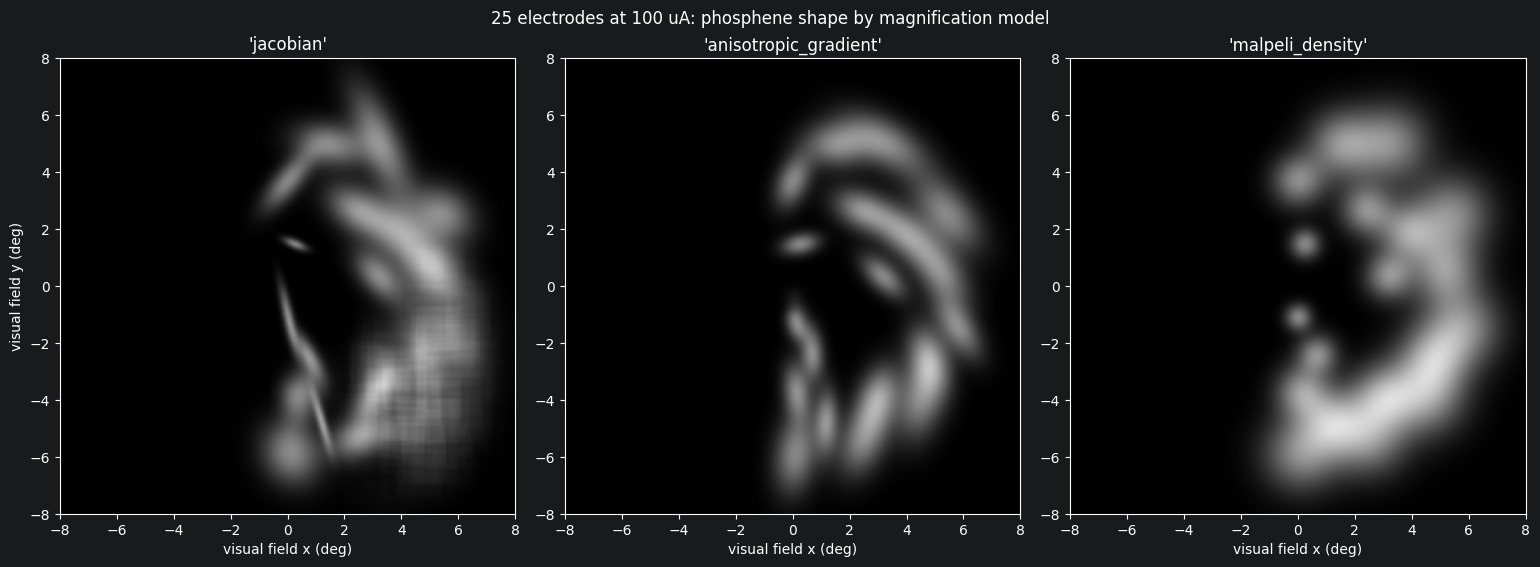

In [11]:
# Render the same 25-electrode stimulation through all three models.
fig, axs = plt.subplots(1, 3, figsize=(15.5, 5.5))
for ax, (name, result) in zip(axs, [('jacobian', jacobian),
                                     ('anisotropic_gradient', anisotropic),
                                     ('malpeli_density', malpeli)]):
    sim = result['simulator']
    sim.reset()
    phosphenes_model = sim(100.e-6 * torch.ones(sim.num_phosphenes))
    ax.imshow(phosphenes_model, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
    ax.set(xlabel='visual field x (deg)', title=f"'{name}'")
axs[0].set_ylabel('visual field y (deg)')
fig.suptitle('25 electrodes at 100 uA: phosphene shape by magnification model')
fig.tight_layout()

#### How much does it matter? Sweeping the current-spread constant K

Every phosphene above is sized from `current_spread.k_ua_per_mm2 = 675`, taken unchanged from macaque V1 (`sigma_mm = 0.5 * sqrt(I / K)`, then converted to degrees by the local `deg/mm` magnification). The config and the README both flag it as unvalidated for LGN; what this cell adds is a direct look at how much of the "blurriness" is explained by that one constant. Electrode *positions* are independent of K (they come from farthest-point sampling over the atlas, before any current is applied), so sweeping K while holding the array fixed isolates its effect on phosphene *size* alone.

`K = 675` is the shipped default. The others are not proposed replacements -- just points on the curve `sigma ~ 1/sqrt(K)`, spaced a decade apart, to show the transition from a fused mass to separated ellipses to small, well-isolated dots.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 1743 voxels per electrode (stride 1, radius 0.185 mm at I_max = 100.0 uA).
INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 57 voxels per electrode (stride 1, radius 0.058 mm at I_max = 100.0 uA).
INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 1 voxels per electrode (stride 1, radius 0.018 mm at I_max = 100.0 uA).


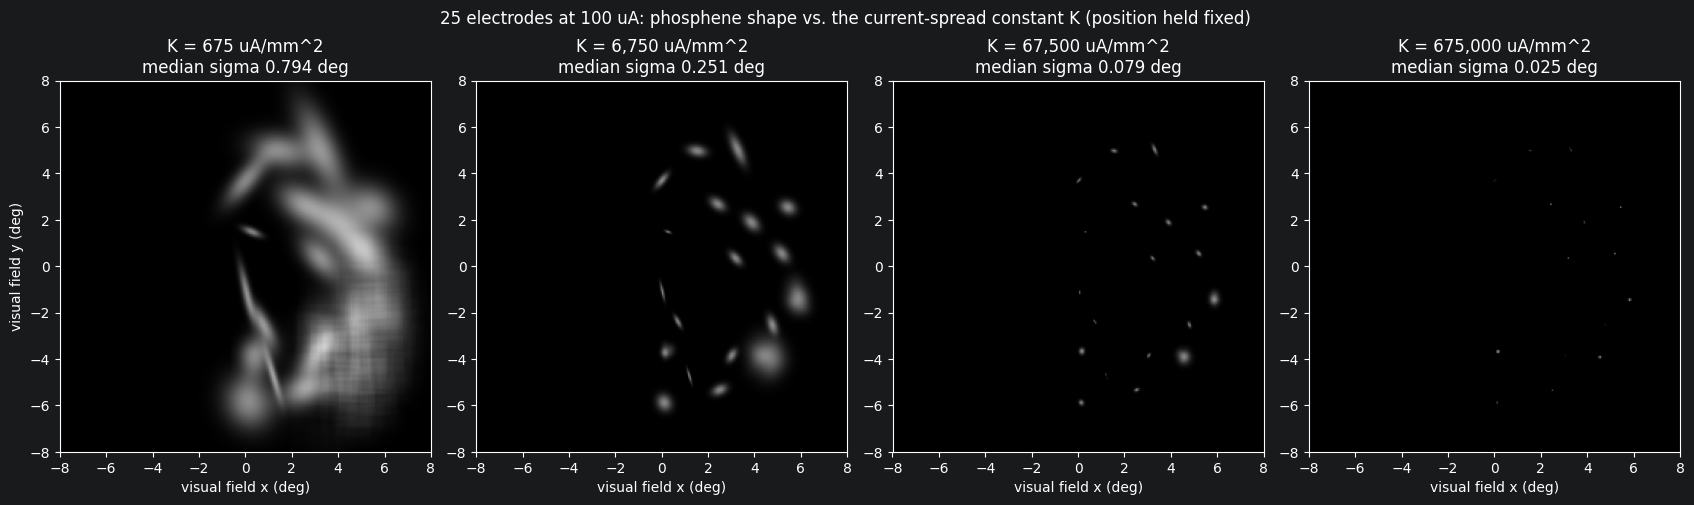

In [12]:
def build_with_k(k_ua_per_mm2, n_electrodes=25):
    p = utils.load_params('../config/params_lgn.yaml')
    p['electrodes']['max_eccentricity_deg'] = 6.0
    p['electrodes']['n_electrodes'] = n_electrodes
    p['current_spread']['k_ua_per_mm2'] = k_ua_per_mm2
    sim, parts = build_simulator(p, atlas_dir=ATLAS_DIR)
    major, minor = sim.array.phosphene_sigma_deg(100.)
    return dict(simulator=sim, major=major, minor=minor)

# 675 is the shipped default (== V1's, unmodified); the rest are just
# points on the sigma ~ 1/sqrt(K) curve, a decade apart each.
k_values = [675.0, 6_750.0, 67_500.0, 675_000.0]
results_k = [build_with_k(k) for k in k_values]

fig, axs = plt.subplots(1, len(k_values), figsize=(4 * len(k_values) + 1, 5))
for ax, k, result in zip(axs, k_values, results_k):
    sim = result['simulator']
    sim.reset()
    phosphenes_k = sim(100.e-6 * torch.ones(sim.num_phosphenes))
    ax.imshow(phosphenes_k, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
    ax.set(xlabel='visual field x (deg)',
           title=f'K = {k:,.0f} uA/mm^2\nmedian sigma {np.nanmedian(result["major"]):.3f} deg')
axs[0].set_ylabel('visual field y (deg)')
fig.suptitle('25 electrodes at 100 uA: phosphene shape vs. the current-spread '
            'constant K (position held fixed)')
fig.tight_layout()

## 2. Atlas models
Instead of letting the simulator spread the electrodes for you, it can be initialized from a list of electrode locations **in the tissue**. Positions are given in Horsley-Clarke stereotaxic millimetres, converted to atlas voxel indices, and the atlas supplies the phosphene location for each.

In [13]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')

# Place a square electrode grid in the tissue
foveal = np.argwhere(atlas.valid & ~atlas.is_ipsi_sentinel()
                     & (atlas.eccentricity_deg <= 5))
center_ml, center_dv, center_ap = index_to_horsley_clarke(
    params, foveal.mean(axis=0))

# The grid lies in the medial-lateral / dorsal-ventral plane at a fixed
# anterior-posterior depth, i.e. in the plane the laminae curve in, so
# the coronal section below shows it face-on.
pitch = 0.4                                     # mm between electrodes
offsets = (np.arange(6) - 2.5) * pitch          # a 6 x 6 grid
ml, dv = np.meshgrid(center_ml + offsets, center_dv + offsets, indexing='ij')
ap = np.full(ml.size, center_ap)
print(f'Grid centre: ML {center_ml:.2f}, DV {center_dv:.2f}, '
      f'AP {center_ap:.2f} mm; {pitch * 1e3:.0f} um pitch.')

# Map the Horsley-Clarke coordinates to atlas voxel indices
coordinates_lgn = np.stack(
    atlas.horsley_clarke_to_index(ml.ravel(), dv.ravel(), ap), axis=-1)

# Keep only the electrodes that landed in reconstructed, non-placeholder tissue.
on_tissue = (atlas.valid[tuple(coordinates_lgn.T)]
             & ~atlas.is_ipsi_sentinel(
                 atlas.inclination[tuple(coordinates_lgn.T)]))
print(f'{on_tissue.sum()} of {on_tissue.size} grid positions are on '
      f'usable tissue.')
coordinates_lgn = coordinates_lgn[on_tissue]

# Initialize simulator from the tissue coordinates
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR,
                                   voxel_indices=coordinates_lgn)
n_phosphenes = simulator.num_phosphenes
phosphene_coords = simulator.array.visual_field

# Reset and call the simulator
stim = 80.e-6 * torch.ones(n_phosphenes) # (All electrodes are activated)
simulator.reset()
phosphenes = simulator(stim)

Grid centre: ML 12.62, DV 3.72, AP 5.63 mm; 400 um pitch.
34 of 36 grid positions are on usable tissue.


INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Text(0.5, 1.0, 'Simulated phosphenes')

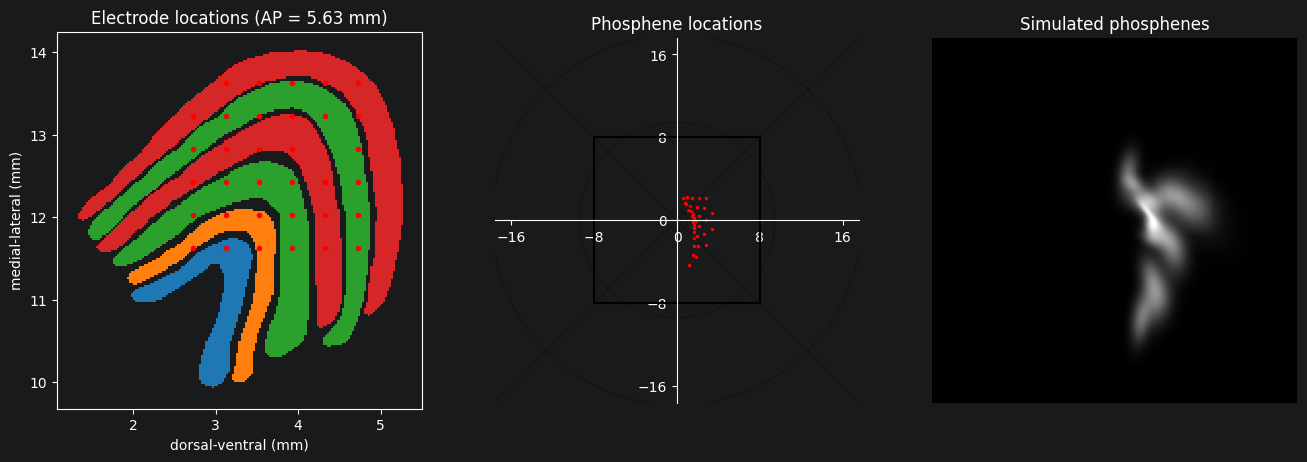

In [14]:
# Visualize
fig, axs = plt.subplots(1,3, figsize=(16,5))

# Plot the electrode locations on a coronal section through the LGN
plot_lgn_section(params, atlas, axs[0], ap_mm=center_ap, field="layer")
electrodes_mm = index_to_horsley_clarke(params, coordinates_lgn)
axs[0].plot(electrodes_mm[:,1], electrodes_mm[:,0], 'r.', markersize=6)
axs[0].set_title(f'Electrode locations (AP = {center_ap:.2f} mm)')

# Plot the phosphene locations in the visual field
axs[1].plot(*phosphene_coords.cartesian, 'r.', markersize=3)
plot_fov(params, axs[1])
axs[1].set_title('Phosphene locations')

# Plot the simulated phosphene image
axs[2].imshow(phosphenes,cmap='gray', origin='lower') # (origin is lower left)
axs[2].axis('off')
axs[2].set_title('Simulated phosphenes')

The coloured bands in the left panel are the four laminar codes in `LAYERS.DAT` - magnocellular 1–2 and parvocellular 3–4, split by eye of origin, which is what makes six bands in section. A regular grid in tissue is *not* regular in the visual field: the same 400 µm pitch spans a fraction of a degree near the foveal representation and several degrees away from it, the grid shears and folds, and an electrode crossing a laminar boundary jumps to the other eye's map of nearly the same point.

#### The inverse: asking for phosphenes at given visual-field positions
`visual_field_targets` runs the lookup the other way, putting each electrode in the tissue nearest a requested percept location. It is nearest-neighbour, not exact - `position_error_deg` reports how far off each one landed, which is nonzero wherever the atlas has no tissue representing that point.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


requested ( 1.0 deg,  -75.0 deg)  ->  realised ( 1.0 deg,  -75.0 deg)   miss 0.00 deg
requested ( 2.0 deg,  -45.0 deg)  ->  realised ( 2.0 deg,  -45.0 deg)   miss 0.00 deg
requested ( 3.0 deg,  -15.0 deg)  ->  realised ( 3.0 deg,  -15.0 deg)   miss 0.00 deg
requested ( 4.0 deg,  +15.0 deg)  ->  realised ( 4.0 deg,  +15.0 deg)   miss 0.00 deg
requested ( 5.0 deg,  +45.0 deg)  ->  realised ( 5.0 deg,  +45.0 deg)   miss 0.00 deg
requested ( 6.0 deg,  +75.0 deg)  ->  realised ( 6.0 deg,  +75.0 deg)   miss 0.00 deg


Text(0.5, 1.0, 'Simulated phosphenes')

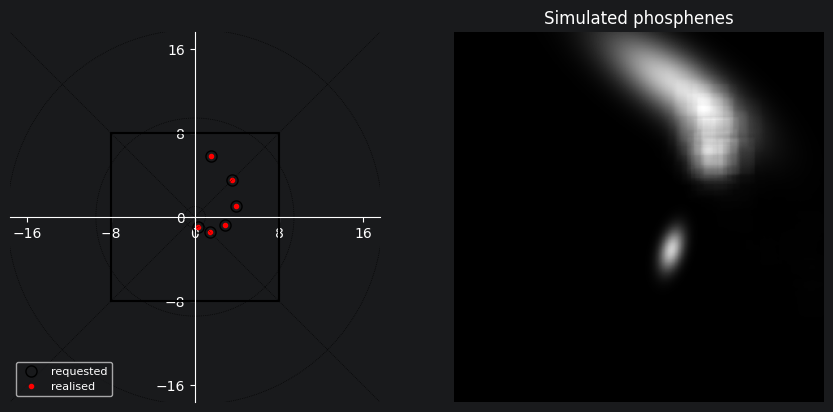

In [15]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')

# Requested phosphene locations (degrees). Inclination is restricted to
# [-90, 90]: one LGN only represents the contralateral hemifield.
eccentricity = np.array([1., 2., 3., 4., 5., 6.])
inclination = np.array([-75., -45., -15., 15., 45., 75.])

simulator, parts = build_simulator(
    params, atlas_dir=ATLAS_DIR,
    visual_field_targets=(eccentricity, inclination))

error = parts['electrode_array'].position_error_deg
for req_e, req_i, got_e, got_i, err in zip(
        eccentricity, inclination, simulator.array.eccentricity_deg,
        simulator.array.inclination_deg, error):
    print(f'requested ({req_e:4.1f} deg, {req_i:+6.1f} deg)  ->  '
          f'realised ({got_e:4.1f} deg, {got_i:+6.1f} deg)   '
          f'miss {err:.2f} deg')

simulator.reset()
phosphenes = simulator(80.e-6 * torch.ones(simulator.num_phosphenes))

fig, axs = plt.subplots(1, 2, figsize=(10.5, 5))
target = Map(r=eccentricity, phi=np.deg2rad(inclination))
axs[0].plot(*target.cartesian, 'ko', markersize=8, fillstyle='none',
            label='requested')
axs[0].plot(*simulator.array.visual_field.cartesian, 'r.', markersize=6,
            label='realised')
plot_fov(params, axs[0])
axs[0].legend(fontsize=8, loc='lower left')
axs[1].imshow(phosphenes, cmap='gray', origin='lower')
axs[1].axis('off')
axs[1].set_title('Simulated phosphenes')

### 3. Stimulation parameters
Pulse width and frequency can be set per electrode alongside amplitude.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


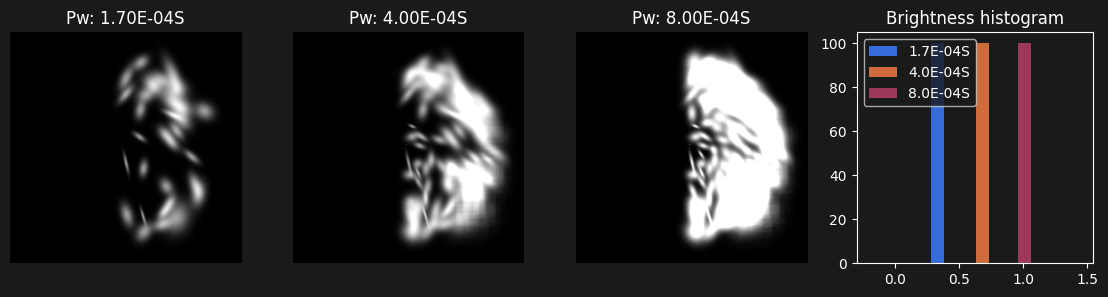

In [16]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
n_phosphenes = 100
params['electrodes']['n_electrodes'] = n_phosphenes
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Plot phosphenes for different pulse widths
stim_amp = 35e-6 # A
freq = 300 # Hz
PWs = np.array([170.,400.,800.])*1e-6 # S

fig, axs = plt.subplots(1,4,figsize=(14,3))
for i,PW in enumerate(PWs):
    simulator.reset()
    stim = stim_amp*torch.ones(n_phosphenes)
    f = freq*torch.ones(n_phosphenes)
    pw = PW*torch.ones(n_phosphenes)
    img = simulator(stim,pw,f)
    axs[i].imshow(img,cmap='gray',origin='lower')
    axs[i].axis('off')
    axs[i].set_title(f'Pw: {PW:0.2E}S')

    # histogram of brightness
    axs[3].hist(to_numpy(simulator.brightness.get()).ravel(), label=f'{PW:0.1E}S')

axs[3].legend()
axs[3].set_title('Brightness histogram')
plt.show()

The temporal dynamics, the rheobase and the brightness saturation curve behind this are inherited from the V1 model unchanged. There is no LGN or thalamic strength-duration data of any kind, so the pulse-width dependence shown here is transplanted, not measured - and chronaxie in particular is a range rather than a number for thalamus (`default_stim.chronaxie_range_s`), because short pulses bias towards activating axons of passage.

## 4. Image preprocessing
An image is turned into phosphenes in three steps: image processing (natural image -> simplified image), stimulus sampling (simplified image -> stimulation vector) and phosphene simulation (stimulation vector -> phosphene image, as above).

#### Image processing - creating a simplified representation of the input image

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


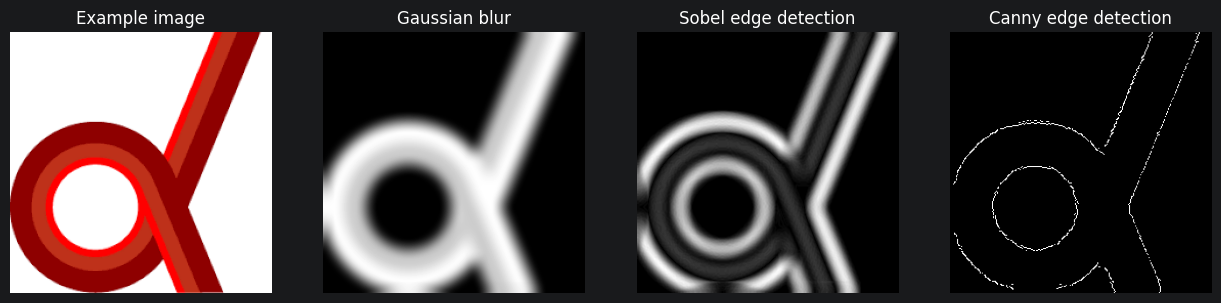

In [17]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
n_phosphenes = 1000
params['electrodes']['n_electrodes'] = n_phosphenes
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Visualize different image processing examples
fig, axs = plt.subplots(1,4, figsize=(15.5,8))

# Example image
img = cv2.imread('../test/data/donders.png')
img = img[::-1] # Flip vertically (origin is lower-left)
axs[0].imshow(img[:,:,::-1], origin='lower') # (Invert color channels)
axs[0].set_title('Example image')

# General preprocessing
resolution = (256,256)
frame = cv2.resize(img, resolution)
img_gray = 255 - cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Gaussian blur
img_blur = cv2.GaussianBlur(img_gray, (21,21), 7)
axs[1].imshow(img_blur, cmap='gray', origin='lower')
axs[1].set_title('Gaussian blur')

# Sobel edge detection
img_sobel = sobel_processor(img_blur)
axs[2].imshow(img_sobel, cmap='gray', origin='lower')
axs[2].set_title('Sobel edge detection')

# Canny edge detection
img_canny = canny_processor(img_blur,threshold_low=70,threshold_high=100)
axs[3].imshow(img_canny, cmap='gray', origin='lower')
axs[3].set_title('Canny edge detection')

for ax in axs.flatten():
    ax.axis('off')

#### Stimulus sampling - mapping an image to stimulation vector
The inbuilt stimulus sampling method samples the pixel intensities at the phosphene locations to obtain a stimulation vector. By default, the pixel values of the sampled image are expected to represent the stimulation amplitude in Ampère.

By setting the rescale argument to True, the stimulus sampling method can be explicitly instructed to remap the pixels values: [0., 1.] or [0, 255] -> [0.,
*stimulus_scale*]. The *stimulus_scale* is specified in the simulator configuration file (100 microampere by default).

The sampling region comes from `sampling.rf_cell_class` / `rf_form`, in-project least-squares fits to Croner & Kaplan (1995)'s `rc(E)` curve for LGN receptive fields - used directly in degrees, with no tissue-to-visual-angle conversion.

In [18]:
##  Obtain the stimulation amplitudes by sampling the image at the phosphene locations.
## The range of the pixel intensities needs to be mapped to the range of stimulation amplitudes.

# Simply set 'rescale=True', which maps pixels in range [0,255] to [0, 100e-6] by default....
stim_gray = simulator.sample_stimulus(img_gray, rescale=True)
stim_blur = simulator.sample_stimulus(img_blur, rescale=True)

# ... or make sure that the pixel values represent the stimulation amplitudes for each region of the input image.
def normalized_rescaling(img, stimulus_scale=100.e-6):
    """Normalize <img> and rescale the pixel intensities in the range [0, <stimulus_scale>].
    The output image represents the stimulation intensity map.
    param stimulus_scale: the stimulation amplitude corresponding to the highest-valued pixel.
    return: image with rescaled pixel values (stimulation intensity map in Ampères)."""
    img_norm = (img-img.min())/(img.max()-img.min())
    return img_norm * stimulus_scale
sobel_rescaled = normalized_rescaling(img_sobel)
canny_rescaled = normalized_rescaling(img_canny)
stim_sobel = simulator.sample_stimulus(sobel_rescaled)
stim_canny = simulator.sample_stimulus(canny_rescaled)

# Print example comparison
print(f'Pixel intensities of the Canny edge detection img.\n'
      f'Before rescaling pixel values: min={img_canny.min()}, max={img_canny.max()}')
print(f'After rescaling pixel values: min={canny_rescaled.min()}, max={canny_rescaled.max()}')

Pixel intensities of the Canny edge detection img.
Before rescaling pixel values: min=0, max=255
After rescaling pixel values: min=0.0, max=0.0001


#### Simulated phosphene images

Text(0.5, 1.0, 'Canny edge detection')

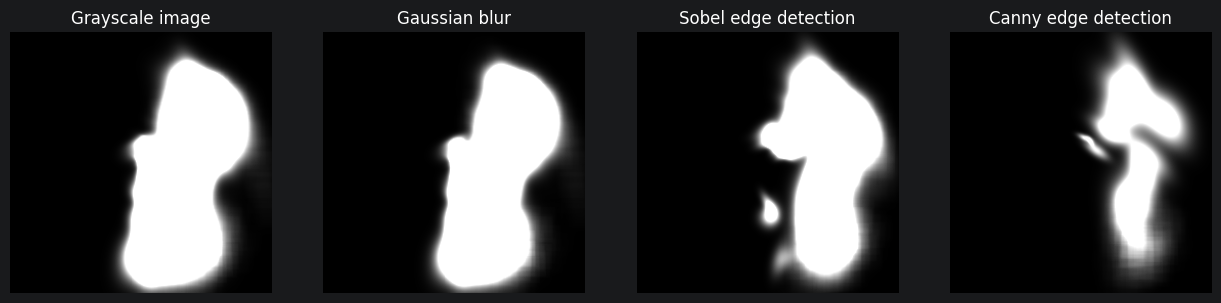

In [19]:
fig, axs = plt.subplots(1,4, figsize=(15.5,8))

# Parse each stimulation vector through the simulator
for i, stim in enumerate([stim_gray, stim_blur, stim_sobel, stim_canny]):
    simulator.reset()
    phosphenes=simulator(stim)
    axs[i].imshow(phosphenes, origin='lower', cmap='gray')

for ax in axs.flatten():
    ax.axis('off')

axs[0].set_title('Grayscale image')
axs[1].set_title('Gaussian blur')
axs[2].set_title('Sobel edge detection')
axs[3].set_title('Canny edge detection')

Only the right half of each image carries phosphenes, for the same reason as in section 1.

The grayscale and blur panels are saturated. 1000 electrodes inside the 6° window sit about 0.24° apart - finer than the phosphenes they produce - so filled regions wash out and only the edge-detected inputs still carry structure. Around 100–200 electrodes is where the shape of the input survives; the size caveat from section 1 applies unchanged.

##### Final note on the stimulus sampling method..
By default, the stim amplitude equals the intensity of the sampled image. So, when working with images with pixels in range [0, 255] or [0., 1.], rescaling the pixel values to [0., *stimulus_scale*] (e.g. [0., 100.e-6] Ampère) is an important step that cannot be omitted.

`dynaphos_lgn.simulator.sample_stimulus` does not raise a warning for suspiciously high, unrescaled pixel values, so skipping `rescale=True` fails silently here. The cell below prints the resulting amplitudes instead, which makes the two-decade difference obvious.

In [20]:
# Omitting the rescaling
stim = simulator.sample_stimulus(img_gray) # <- Not ok: these are pixel values, not amperes.
print(f'No rescaling      : max stim = {stim.max():.3E} A   <- ~4 decades too large')

# Using the inbuilt rescaling
stim = simulator.sample_stimulus(img_gray, rescale=True) # <- This is ok.
print(f'rescale=True      : max stim = {stim.max():.3E} A')

# Provide pixels values in range [0., 100e-6]
activation_mask = (img_gray / 255) * 100.e-6
stim = simulator.sample_stimulus(activation_mask) # <- This is also ok.
print(f'pre-scaled pixels : max stim = {stim.max():.3E} A')

No rescaling      : max stim = 8.392E-01 A   <- ~4 decades too large
rescale=True      : max stim = 8.392E-05 A
pre-scaled pixels : max stim = 8.392E-05 A


## 5. Example video

In [21]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
n_phosphenes = 1000
params['electrodes']['n_electrodes'] = n_phosphenes
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Stop after a couple of seconds
framerate = params['run']['fps']
max_n_frames = 2*framerate

# Load the videostream
cap = cv2.VideoCapture('./example_video.mp4')
if not cap.isOpened():
    print('Unable to read file :(')

# Set the output stream
fourcc = cv2.VideoWriter_fourcc(*'XVID') #codec
out = cv2.VideoWriter('clip_phosphenes_lgn.avi', fourcc, framerate, (512,256),False)

# Loop over frames
frame_nr = 0
while frame_nr<max_n_frames:
    # load next frame
    ret, frame = cap.read()
    frame_nr+=1

    if not ret:
        break

    # to one channel, grayscale
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # get square if frame is not square
    if frame.shape[0] != frame.shape[1]:
        shortest_side = min(frame.shape)
        frame = frame[frame.shape[0]//2-shortest_side//2:frame.shape[0]//2+shortest_side//2,
                      frame.shape[1]//2-shortest_side//2:frame.shape[1]//2+shortest_side//2]

    # preprocess: to resize, grayscale and blur
    frame = cv2.resize(frame, (256,256))
    frame = cv2.GaussianBlur(frame, (21,21), 5)

    # edge/contour detector
    processed_img = sobel_processor(frame)
    processed_img = frame
    stim_pattern = simulator.sample_stimulus(processed_img, rescale=True)

    # Generate phosphenes
    phs = simulator(stim_pattern).clamp(0,1)
    phs = to_numpy(phs)*255

    # Concatenate results
    # cat = np.concatenate([frame, processed_img, phs], axis=1).astype('uint8')
    cat = np.concatenate([processed_img, phs], axis=1).astype('uint8')

    out.write(cat)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()

cv2.destroyAllWindows()
print(f'Wrote {frame_nr - 1} frames to clip_phosphenes_lgn.avi.')

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Wrote 69 frames to clip_phosphenes_lgn.avi.


## 6. Internal parameters

In [22]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
n_phosphenes = 5
params['electrodes']['n_electrodes'] = n_phosphenes
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# One example frame with random stimulation
simulator.reset()
phosphenes = simulator(100e-6*torch.rand(n_phosphenes))

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


#### Phosphene maps
The phosphene_maps indicate the distance in degrees of visual angle from the center of each phosphene.

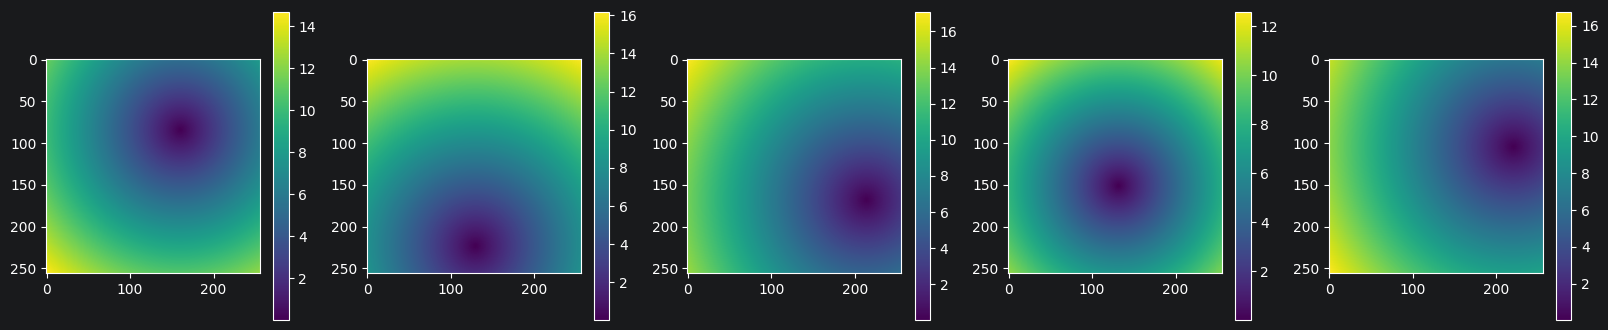

In [23]:
fig, axs= plt.subplots(1,5,figsize=(20,4))
for i, ax in enumerate(axs.flatten()):
    h = ax.imshow(to_numpy(simulator.phosphene_maps[i]))
    fig.colorbar(h)

#### Internal states
Several of the simulators internal states can be accessed, such as the *threshold*, *activation*, *brightness* and *trace*.

In [24]:
# For instance, the perception thresholds for each phosphene can be accessed..
thresholds = simulator.threshold.get()
print(thresholds)

# ... and reinitialized manually.
simulator.threshold.reinitialize(torch.rand_like(thresholds)*1e-7)
thresholds = simulator.threshold.get()
print(thresholds)

tensor([[[1.7817e-07]],

        [[2.1085e-07]],

        [[3.3231e-08]],

        [[9.2352e-08]],

        [[9.2176e-08]]])
tensor([[[6.0090e-08]],

        [[2.5657e-08]],

        [[7.9364e-08]],

        [[9.4077e-08]],

        [[1.3319e-08]]])


C:\Users\sebas\PycharmProjects\dynaphos_LGN\dynaphos\utils.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, **data_kwargs)


In [25]:
# The internal states can be obtained at once using the get_state method
all_states = simulator.get_state() # get all internal parameters
print(all_states['brightness'])

tensor([[[0.4427]],

        [[0.4653]],

        [[0.1646]],

        [[0.4961]],

        [[0.1676]]])


`get_state` carries four entries that are LGN-specific:

- `sigma_major` / `sigma_minor` - the two phosphene axes in degrees, from the two principal magnifications of the atlas's local Jacobian, so phosphenes are ellipses whose elongation and orientation come from the tissue.
- `layer_activation` / `recruited_cells` - how much of each of the six laminae the current reached. `layer_activation_table()` is the readable view.

Phosphene sigmas (deg), major vs minor:
[[0.72472453 0.41723803]
 [0.7648966  0.5879672 ]
 [0.48709112 0.3931001 ]
 [0.29417646 0.10903837]
 [0.9491186  0.47112384]]


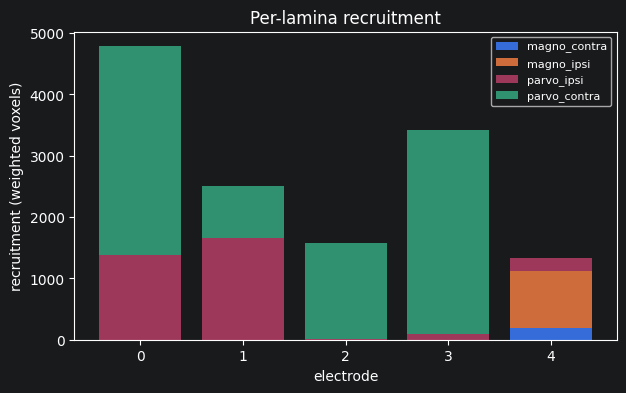

In [26]:
# Per-lamina recruitment for the last frame
table = simulator.layer_activation_table()

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(simulator.num_phosphenes)
bottom = np.zeros(simulator.num_phosphenes)
for name, values in table.items():
    values = np.atleast_1d(values).ravel()
    ax.bar(x, values, bottom=bottom, label=name)
    bottom = bottom + values
ax.set(xlabel='electrode', ylabel='recruitment (weighted voxels)',
       title='Per-lamina recruitment')
ax.legend(fontsize=8)

print('Phosphene sigmas (deg), major vs minor:')
print(np.stack([to_numpy(all_states['sigma_major']).ravel(),
                to_numpy(all_states['sigma_minor']).ravel()], axis=-1))

## 7. Computational optimization
The simulation framework is created in pytorch and makes use of differentiable operations to enable computational optimization.

Note: The code below is an extremely simplified 'mock example' of computational optimization of the stimulation parameters. It is *not* part of the the end-to-end optimization paradigm used in the experiments of the publication. That end-to-end optimization framework can be found in  [**this repository**](https://github.com/neuralcodinglab/viseon/tree/dynaphos-paper).

#### Mock example of computational optimization

In [27]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
n_phosphenes = 5
params['electrodes']['n_electrodes'] = n_phosphenes
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Optimization target
target_brightness = 0.5 * torch.ones(simulator.shape)

# Initialize an 'encoder' which will be optimized
# (note: not using a real DNN encoder here, but just a tensor that scales the stimulation)
base_stim = 100e-6 * torch.ones(n_phosphenes)
encoder = torch.nn.Parameter(torch.rand(n_phosphenes), requires_grad=True)
optimizer = torch.optim.Adam([encoder],lr=0.05)
print(encoder)

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Parameter containing:
tensor([0.8823, 0.9150, 0.3829, 0.9593, 0.3904], requires_grad=True)


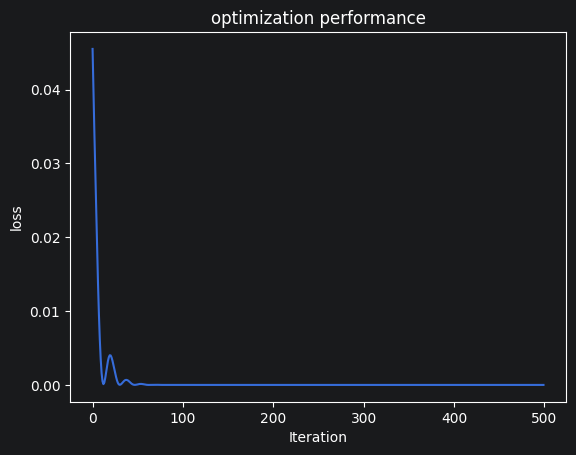

Parameter containing:
tensor([0.9648, 0.9648, 0.9648, 0.9648, 0.9648], requires_grad=True)


In [28]:
# Track optimization performance
hist = {'brightness': [],
        'stim': [],
        'encoder': [],
        'loss': []}

# Iteratively update the 'encoder'
for _ in range(500):
    optimizer.zero_grad()
    simulator.reset()
    stim = base_stim * encoder
    phosphenes = simulator(stim)
    brightness = simulator.get_state()['brightness']
    mse = torch.nn.functional.mse_loss(brightness, target_brightness)
    mse.backward()
    optimizer.step()

    # Track optimization performance
    hist['stim'].append(stim.detach().clone())
    hist['encoder'].append(encoder.detach().clone())
    hist['brightness'].append(brightness.detach().clone())
    hist['loss'].append(mse.item())

fig, ax = plt.subplots()
ax.plot(hist['loss'])
ax.set(xlabel='Iteration', ylabel='loss', title='optimization performance')
plt.show()

print(encoder)

One thing the LGN config does differently is worth stating, because it is a model change and not a solver trick. `thresholding.soft_threshold` is **on** by default: the detection gate is a logistic psychometric curve rather than Dynaphos's hard step. With a hard threshold, an electrode below threshold has exactly zero gradient and can never learn to cross it - which is precisely the electrode an optimiser most needs to move. Set `params['thresholding']['soft_threshold'] = False` to recover the V1 behaviour, and say which one you used when reporting.

Gradients reach amplitude, pulse width and frequency through the image, the recruitment weights and the activation state. They do **not** reach voxel positions or layer labels: those are fixed buffers, so electrode *placement* is not optimisable here (see the README's known gaps).